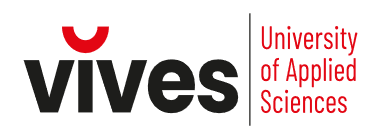<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **A GENTLE INTRODUCTION TO GRADIENT DESCENT**

In this series of exercises we will implement the **Stochastic Gradient Descent** (SGD) algorithm step by step in order to apply **simple linear regression** to a very simple dataset. In the end, two more exercises with more realistic datasets are given, and we will also apply the Scikit-Learn class for linear regression.

The first exercises are based on chapter 3 on linear regression of the textbook ["Grokking Machine Learning"](https://www.manning.com/books/grokking-machine-learning). In [this YouTube video](https://youtu.be/wYPUhge9w5c?si=MGOKg_rK-A2C7kBT), the author, Luis Serrano, summarizes this chapter. The video is highly recommended for students who are not familiar with the mathematical concepts of slope and intercept in a straight line.

## A simple example

As mentioned, we start with a very simple dataset with home prices. You can safely call that the 'Hello World' of the regression in machine learning...

### Exercise 1

Consider the following Pandas `Dataframe`. Explore the data by calling method `describe`, and plot the data in a scatterplot where `x='num_rooms'` and `y='price'`.

In [196]:
import pandas as pd

# Creating the DataFrame
data = {
    'num_rooms': [1, 2, 3, 5, 6, 7],
    'price': [150, 200, 250, 350, 400, 450]
}

houses = pd.DataFrame(data)

# Display the DataFrame
houses

,num_rooms,price
0,1,150
1,2,200
2,3,250
3,5,350
4,6,400
5,7,450


Calling method `describe()`:

In [197]:
# calculating summary statistics
houses.describe().T  # T transposes the table

,count,mean,std,min,25%,50%,75%,max
num_rooms,6.0,4.0,2.366432,1.0,2.25,4.0,5.75,7.0
price,6.0,300.0,118.321596,150.0,212.50,300.0,387.50,450.0


Making the scatterplot using method `plot.scatter()`:

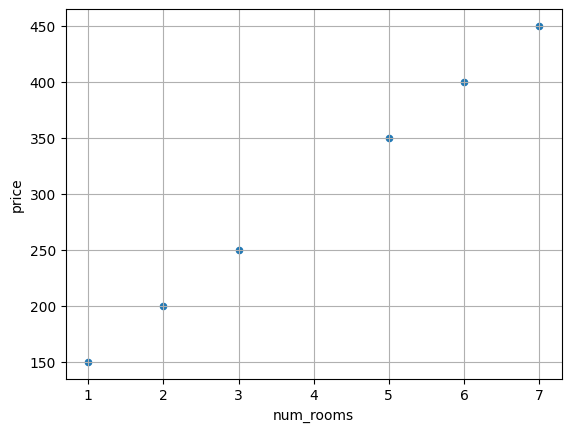

In [198]:
# making a scatter plot of the data
houses.plot.scatter (x="num_rooms", y="price", grid=True);

Now define a function `calculate_price()` that implements the following formula:

```python
price = 100.0 + 50.0 * num_rooms
```

The input argument of the function is the number of rooms `num_rooms`; the return value of the function is the house price `price`.

Use your function to calculate the price of a house having 4 rooms. Add this example to the dataframe and make a new scatterplot using the extended dataframe.

In [199]:
def calculate_price(num_rooms):
    """
    calculate house price given the number of rooms in the house
    num_rooms: number of rooms (int)
    returns house price (float)
    """
    return 100.0 + 50.0 * num_rooms

In [200]:
# Calculate the price for a house with 4 rooms
n = 4
new_price = calculate_price(n)

# Create a new DataFrame with the new data point
new_data = pd.DataFrame({'num_rooms': [n], 'price': [new_price]})

# Concatenate the new data to the original DataFrame
houses = pd.concat([houses, new_data])

# Sort the rows by number of rooms
houses = houses.sort_values(by='num_rooms', ignore_index=True)

# Visualize the DataFrame
houses

,num_rooms,price
0,1,150.0
1,2,200.0
2,3,250.0
3,4,300.0
4,5,350.0
5,6,400.0
6,7,450.0


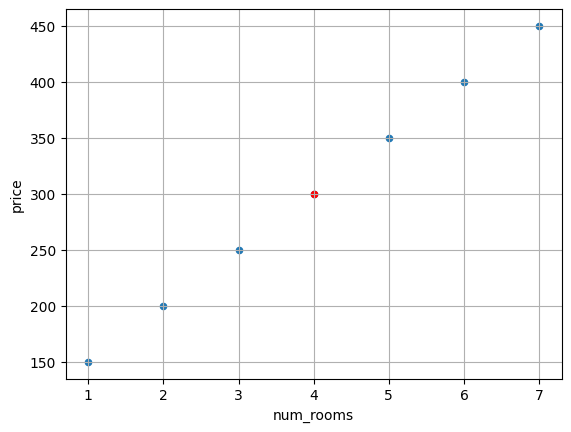

In [201]:
# plot all data points
ax = houses.plot.scatter (x="num_rooms", y="price");
# color new data point in red
houses[houses.num_rooms == 4].plot.scatter(x="num_rooms", y="price", c='red', grid=True, ax=ax);

## A second problem

The previous exercise was of course very simple.
Now let's look at a similar but slightly more realistic dataset (although it is still very simple...)

### Exercise 2

Consider the following DataFrame. Again, explore the data, and plot the data in a scatterplot.

Notice that the table now contains a row for a house with 4 rooms, but with the price indicated as `NaN`, which means "Not-a-Number" implying the price is not known. This is called a **missing value**. When plotting, this row is automatically skipped.

Replace the `NaN`-value in your data frame with the price that you have calculated with the function `calculate_price()`. Try to replace the missing value in a smart way; for example, by using [boolean indexing](https://www.geeksforgeeks.org/boolean-indexing-in-pandas/). Make a scatterplot again with the adjusted data frame.

In [202]:
import numpy as np

# Creating the DataFrame
data = {
    'num_rooms': [1, 2, 3, 4, 5, 6, 7],
    'price': [155.0, 197.0, 244.0, np.NaN, 356.0, 407.0, 448.0]  # NaN stands for Not-a-Number
}

houses = pd.DataFrame(data)

# Display the DataFrame
houses

,num_rooms,price
0,1,155.0
1,2,197.0
2,3,244.0
3,4,NaN
4,5,356.0
5,6,407.0
6,7,448.0


In [203]:
# calculate summary statistics
houses.describe().T

,count,mean,std,min,25%,50%,75%,max
num_rooms,7.0,4.000000,2.160247,1.0,2.50,4.0,5.50,7.0
price,6.0,301.166667,119.374062,155.0,208.75,300.0,394.25,448.0


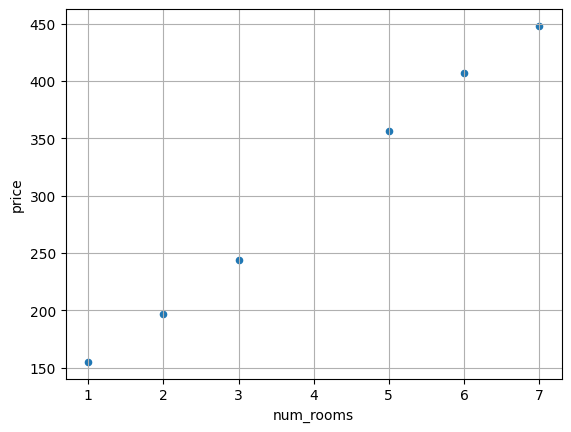

In [204]:
# plot all data points
houses.plot.scatter(x ='num_rooms', y='price', grid=True);

In [205]:
# replace NaN
n = 4
houses.loc[houses.num_rooms==n, "price"] = calculate_price(n)
houses

,num_rooms,price
0,1,155.0
1,2,197.0
2,3,244.0
3,4,300.0
4,5,356.0
5,6,407.0
6,7,448.0


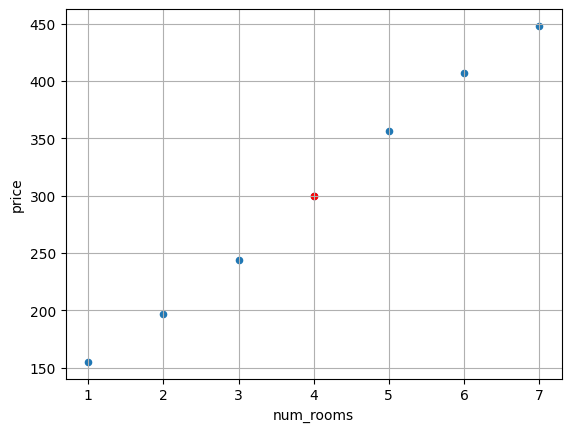

In [206]:
# plot all data points
ax = houses.plot.scatter (x="num_rooms", y="price");
# color new data point in red
houses[houses.num_rooms == 4].plot.scatter(x="num_rooms", y="price", c='red', grid=True, ax=ax);

## A first algorithm

In Machine Learning, the objective is to apply an **algorithm** to the dataset that results in a **model** with which we can predict the price of a house with any rooms. Now let's work out such an algorithm step by step!

### Exercise 3

We start by first defining a model ourselves with which we can make **predictions** about the price of a house. The house price is therefore the **target**. In fact, in the previous exercises we have already defined such a model to predict that price using the number of rooms, which we call a **feature**.

Define a function `predict_price()` accepting the following input arguments: `base_price`, `price_per_room`, and `num_rooms`. The base price may be considered as the price of a house without rooms. The output of the function is the `price` of the house, which is calculated as follows:

```python
price = base_price + price_per_room * num_rooms
```

Here, we define a linear model with model parameters `base_price` and `price_per_room`. These parameters are used to map feature `num_rooms` to target `price`. The model can be represented by a straight line described by the following equation:

> $y = ax + b$

In this equation, $x$ is the `num_rooms`, $y$ is the `price`, `base_price` corresponds to **intercept** $b$, and the `price_per_room` to **slope** $a$. Intercept and slope are called the **model parameters**.

In [207]:
def predict_price(base_price, price_per_room, num_rooms):
    """
    Calculate house price given a base price, the price per room, and the number of rooms
    base_price: base price (float)
    price_per_room: price per room (float)
    num_rooms: number of rooms (int or array_like)
    returns: house price (float)
    """
    return base_price + price_per_room * num_rooms

In [208]:
# Calculating price for 1 house
base_price = 100.0
price_per_room = 50.0
num_rooms = 4
predict_price(base_price, price_per_room, num_rooms)

300.0

Does your function also work with NumPy arrays? Test this out!

In [209]:
# Calculating price for several houses using a numpy array
import numpy as np
num_rooms = np.arange(1, 8, dtype=int)  # numpy array [1, 2, 3, 4, 5, 6, 7]
predict_price(base_price, price_per_room, num_rooms)

array([150., 200., 250., 300., 350., 400., 450.])

### Exercise 4

At first glance, this model already gives quite accurate predictions, but machine learning is about applying algorithms that *learn from the data*, and so we are not supposed to "invent" models ourselves.

In concrete terms, we want to develop an algorithm here that creates a model to make predictions of the price of houses, where those *predictions are as close as possible to the house prices from our dataset*. So we have to develop a **supervised learning** algorithm because the dataset already contains examples of our target, namely the price of the houses.

We start with a simple trick: we adjust the parameters slightly depending on whether the given price is higher or lower than the predicted price. Four cases are considered:

1. If the price of the house is higher than the price the model predicts, and the
number of rooms is positive:
 - add 1 cent to the price per room,
 - add 1 cent to the base price.

2. If the price of the house is higher than the price the model predicts, and the
number of rooms is negative:
 - subtract 1 cent from the price per room,
 - add 1 cent to the base price.

3. If the price of the house is lower than the price the model predicts, and the
number of rooms is negative:
 - add 1 cent to the price per room,
 - subtract 1 cent from the base price.

4. If the price of the house is lower than the price the model predicts, and the
number of rooms is positive:
 - subtract 1 cent from the price per room
 - subtract 1 cent from the base price.

Define a function `simple_trick()` that converts the next algorithm in pseudocode to python code. The input parameters of the function are: `base_price`, `price_per_room`, `num_rooms`, `price`, and `step`. The last parameter is to the default value of 0.01, which corresponds to the 1 cent from the algorithm above. The output is a tuple with the adapted `base_price` and` price_per_room`. Make use of the function `predict_price()` from the previous exercise and test your code!

*Note:* In reality, the number of rooms can never be negative, but mathematically this is possible, and so we must also take into account those unrealistic cases 2 and 3. The figure below portrays the four cases.

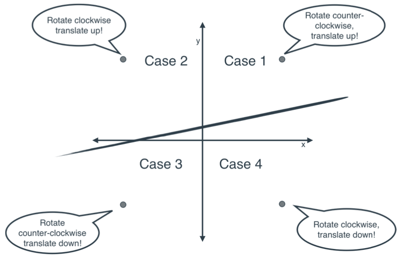

In [210]:
def simple_trick(base_price, price_per_room, num_rooms, price, step=0.01):
    """
    Adjust base price and price per room given the number of rooms and the house price
    base_price: base price (float)
    price_per_room: price per room (float)
    num_rooms: number of rooms (int)
    price: house price (float)
    step: determines the adjustment in price (float, default is 0.01)
    returns a tuple with the adjusted parameters (base_price, price_per_room)
    """
    predicted_price = predict_price(base_price, price_per_room, num_rooms)
    if price > predicted_price and num_rooms > 0: # case 1
        price_per_room += step
        base_price += step
    if price > predicted_price and num_rooms < 0: # case 2
        price_per_room -= step
        base_price += step
    if price < predicted_price and num_rooms < 0: # case 3
        price_per_room += step
        base_price -= step
    if price < predicted_price and num_rooms > 0: # case 4
        price_per_room -= step
        base_price -= step
    return base_price, price_per_room

In [211]:
base_price, price_per_room = 100, 50
print(simple_trick(base_price, price_per_room, num_rooms=1, price=155))  # case 1
print(simple_trick(base_price, price_per_room, num_rooms=-1, price=55))  # case 2
print(simple_trick(base_price, price_per_room, num_rooms=-3, price=-55)) # case 3
print(simple_trick(base_price, price_per_room, num_rooms=3, price=125))  # case 4

(100.01, 50.01)
(100.01, 49.99)
(99.99, 50.01)
(99.99, 49.99)


### Exercise 5

The next step is to implement a simple algorithm that uses our simple trick from the previous exercise.

Define a function `simple_algorithm()` that receives a Pandas DataFrame as input with columns `num_rooms` and `price`. This function also has `num_iterations` as input parameter and `step` with 0.01 as default value.

The function first determines a random `base_price` and `price_per_room`. Then it adjusts this `base_price` and `price_per_room` by calling the `simple_trick()` function from the previous exercise. This is repeated `num_iterations` times. The `num_rooms` and `price` input arguments for this function are taken from the dataset, whereby an example (record or row) from this DataFrame is randomly chosen in each iteration.

Pseudocode:

0. *Initialization:* Start with random values ​for the base price and the price per room

1. *Iterations:* Repeat frequently
  - Choose a random house from the dataset
  - Use this data point to adjust the basic price and price per room so that the model predicts the price of the house better

2. *Output:* Return the final base price and price per room
`` `

In [212]:
def simple_algorithm (houses, num_iterations, step=0.01):
    """
    Naive algorithm to derive the optimal values ​​for base price and price per room from a given dataset
    houses: dataset with 'num_rooms' and 'price' as feature and target (Pandas DataFrame)
    num_iterations: number of iterations (int)
    step: determines the adjustment in price (float, default value is 0.01)
    returns tuple with adjusted parameters (base_price, price_per_room)
    """
    base_price, price_per_room = np.random.random(), np.random.random()
    for _ in range(num_iterations):
        random_house = houses.sample(n=1)  # select 1 random house from the dataset
        num_rooms = random_house['num_rooms'].values.item()
        price = random_house['price'].values.item()
        base_price, price_per_room = simple_trick(base_price, price_per_room, num_rooms, price, step)
    return base_price, price_per_room

Now apply the function to the `houses` dataset:

In [213]:
np.random.seed(42)  # Set a global random seed
base_Price, price_per_room = simple_algorithm (houses, 5000)
base_price, price_per_room

(100, 50.95071430640835)

Make a plot of the regression line that the algorithm has found.

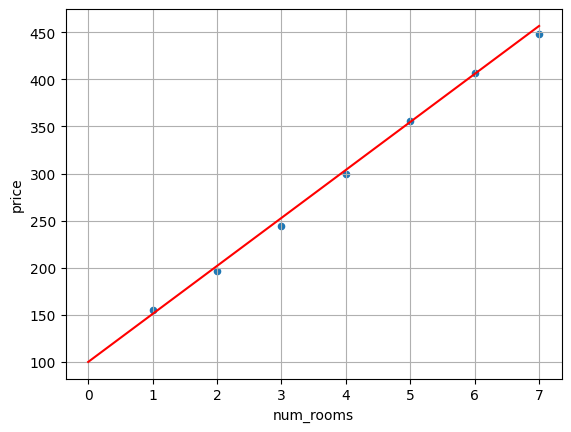

In [214]:
from matplotlib import pyplot as plt

# scatter plot of data points
ax = houses.plot.scatter (x="num_rooms", y='price', grid=True)

# plot of regression line
num_rooms_range = np.arange(0, 8)
ax.plot(num_rooms_range, predict_price(base_price, price_per_room, num_rooms_range), 'r');

## A better algorithm

Our naive algorithm is already working pretty well! But we can do better, because we can apply a mathematical 'trick' and adjust the parameters using the gradient!

### Exercise 6

Define a function `delta_trick()` that does the same as the function `simple_trick()`, but adjusts the parameters as follows:  

```
1) delta = learning_rate * (price - prediction)
2) delta2 = delta * num_rooms
3) price_per_room += delta2
4) base_price += delta
```

The input parameters of the function are: `base_price`, `price_per_room`, `num_rooms`, `price`, and `learning_rate`. The last parameter, the **learning rate**, should have a default value of 0.01, which corresponds to the `step` input argument from the previous algorithm. The output should be a tuple with the updated `base_price` and `price_per_room`.  

Make use of the function `predict_price()` from the previous exercise and test your code!

In [215]:
def delta_trick(base_price, price_per_room, num_rooms, price, learning_rate=0.01):
    '''
    Adjust base price and price per room given the number of rooms and the house price
    base_price: base price (float)
    price_per_room: price per room (float)
    num_rooms: the number of rooms (int)
    price: the house price (float)
    learning_rate: determines the adjustment in price (float, default 0.01)
    returns tuple with adjusted parameters (base_price, price_per_room)
    '''
    predicted_price = predict_price(base_price, price_per_room, num_rooms)
    delta = learning_rate * (price - predicted_price)
    delta2 = delta * num_rooms
    price_per_room += delta2
    base_price += delta
    return base_price, price_per_room

In [216]:
base_price, price_per_room = 100, 50
print(delta_trick(base_price, price_per_room, num_rooms=1, price=155))   # case 1
print(delta_trick(base_price, price_per_room, num_rooms=-1, price=55))   # case 2
print(delta_trick(base_price, price_per_room, num_rooms=-3, price=-55))  # case 3
print(delta_trick(base_price, price_per_room, num_rooms=3, price=125))   # case 4

(100.05, 50.05)
(100.05, 49.95)
(99.95, 50.15)
(98.75, 46.25)


### Exercise 7

Now define a function `better_algorithm()` that does the same as the function `simple_algorithm()`, but applies the `delta_trick()` function instead of `simple_trick()`.  

The function takes a Pandas DataFrame as input with the columns `num_rooms` and `price`. It also has `num_iterations` as an input parameter, and `learning_rate`, which defaults to 0.01.  

First, a random `base_price` and `price_per_room` are generated. Then, the function updates `base_price` and `price_per_room` `num_iterations` times by calling the `delta_trick()` function from the previous exercise.  

The `num_rooms` and `price` input arguments for this function are taken from the DataFrame, where in each iteration, a **random example** (record or row) from the DataFrame is selected.

In [217]:
def better_algorithm(dataset, num_iterations, learning_rate=0.01):
    '''
    Better algorithm to derive the optimal values for base price and price per room from a given dataset
    dataset: dataset with 'num_rooms' and 'price' as feature and target (Pandas DataFrame)
    num_iterations: the number of iterations (int)
    learning_rate: determines the adjustment in price (float, default 0.01)
    returns tuple with adjusted parameters (base_price, price_per_room)
    '''
    base_price, price_per_room = np.random.random(), np.random.random()
    for _ in range(num_iterations):
        random_house = houses.sample(n=1)  # select 1 random house from the dataset
        num_rooms = random_house['num_rooms'].values.item()
        price = random_house['price'].values.item()
        base_price, price_per_room = delta_trick(base_price, price_per_room, num_rooms, price, learning_rate)
    return base_price, price_per_room

Apply the function again to the `houses` dataset:

In [218]:
np.random.seed(42)  # Set a global random seed
base_price, price_per_room = better_algorithm(houses, 5000)
(base_price, price_per_room)

(99.65304126638345, 50.322369683647665)

And make a plot of the regression line that the algorithm has found:

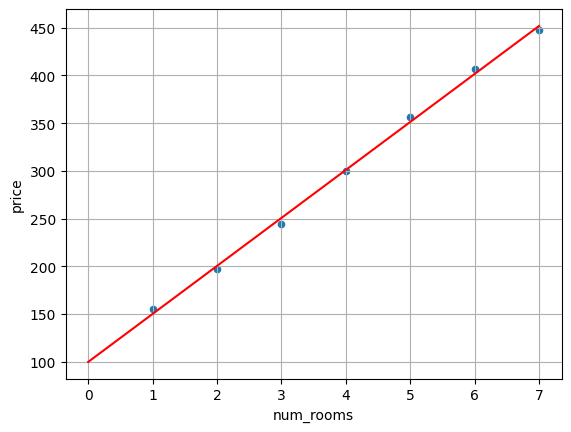

In [219]:
# scatter plot of data points
ax = houses.plot.scatter (x="num_rooms", y='price', grid=True)

# plot of regression line
num_rooms_range = np.arange(0, 8)
ax.plot(num_rooms_range, predict_price(base_price, price_per_room, num_rooms_range), 'r');

It is difficult to see whether this regression line is closer to the data points than the one found by our simple algorithm, but this new algorithm is certainly more effective. You can try both algorithms with different numbers of iterations and see the difference for yourself!

## Mathematical derivation

Actually, the better algorithm from the previous exercise is the **Stochastic Gradient Descent** algorithm, which is also used for training neural networks in deep learning! The mathematical "delta trick" comes down to adjusting the parameters by applying the gradient of the loss function.

The mathemical derivation has already been discussed in the introduction notebook of this topic. Let's briefly recap this here. Recall that the parameters, the slope $a$ and the intercept $b$, are modified during iteration $k$ using the **gradient of the loss function** $L$, which consists of the partial derivates of $L$ with respect to these parameters:

> $a_k = a_{k-1} - \alpha \dfrac{\delta L}{\delta a}$

> $b_k = b_{k-1} - \alpha \dfrac{\delta L}{\delta b}$

with $\alpha$ the learning rate. The loss function $L$ is defined as the sum of squared errors (SSE):

> $L = \dfrac{1}{2}\sum_i(y_i-\hat{y}_i)^2$

with $y_i$ the true target of data point $i$, and $\hat{y}_i$ its prediction defined as:

> $\hat{y}_i = ax_i + b$

where $x_i$ is the feature of data point $i$. Stochastic Gradient Descent uses for each iteration $k$ a random data point $i$ from the dataset to approximate these partial derivatives:

> $\dfrac{\delta L}{\delta a} \approx -(y_i-\hat{y}_i)x_i$

> $\dfrac{\delta L}{\delta b} \approx -(y_i-\hat{y}_i)$

Introducting these approximations into the equations for adjusting $a$ and $b$ gives:

> $a_k = a_{k-1} + \alpha (y_i-\hat{y}_i)x_i$

> $b_k = b_{k-1} + \alpha (y_i-\hat{y}_i)$

If we define $\delta$ as:

> $\delta= \alpha (y_i-\hat{y}_i)$

then we finally get the formulas used in the `delta_trick` function:

> $a_k = a_{k-1} + \delta x_i$

> $b_k = b_{k-1} + \delta$

Recall that in our example $a$ is the `price_per_room`, $b$ is the `base_price`, $x$ is the `num_rooms`, and $y$ is the `price`.




## Final algorithm

In the next exercise, we will write the code of the better algorithm in a more generic way and using the correct machine learning terminology. To do so, we introduce **epochs**: we will still iterate through the data points randomly, but now we will ensure that all data points are covered during a single iteration or epoch. This means we will now have two loops:  
- An *inner loop* that iterates through all data points once in a random order.  
- An *outer loop* that controls the number of epochs.

The **number of epochs** is now also passed as a parameter to the function, and like the learning rate, it is a **hyperparameter**, because it needs to be defined by the user.

### Exercise 8

Now, write a generic function `SGD` that implements the Stochastic Gradient Descent (SGD) algorithm using the concept of *epochs*, as explained above.

Apply this function to the `houses` dataset and plot your results. Also, try to track and plot the progression of the loss function. Can you also create a contour plot of the loss function and draw the path that the SGD algorithm followed to ultimately find the optimal values for `a` and `b`, which correspond to the minimum of the loss function?

In [220]:
# The Stochastic Gradient Descent (SGD) Algorithm

import numpy as np

def SGD(x, y, n_epochs, alpha, seed=None):
    """
    Stochastic Gradient Descent (SGD) algorithm for simple linear regression

    Input parameters:
    - x: array with values of the independent variable (length is n)
    - y: array with corresponding values of the dependent variable (length is n)
    - n_epochs: integer determining the number of epochs
    - alpha: float defining the learning rate
    - seed (optional): seed for the random number generator

    Return values:
    - a: array with slope derived after each epoch (length is n_epochs)
    - b: array with intercept derived after each epoch (length is n_epochs)
    - L: array with SSE calculated after each epoch (length is n_epochs)

    The optimal values for slope and intercept are a[-1] en b[-1],
    and the corresponding SSE is L[-1]
    """

    # initialisation
    if seed is not None: np.random.seed(seed)
    a, b = np.random.rand(), np.random.rand()
    a_path, b_path = [], []  # keep track of a and b derived after each epoch
    L = []  # keep track of loss score calculated after each epoch
    idx = list(range(len(x)))  # indices of the data points

    # outer loop: epochs
    for _ in range(n_epochs):
        np.random.shuffle(idx)  # shuffle indices

        # inner loop: data points
        for i in idx:
            yp = a * x[i] + b  # prediction
            delta = alpha * (y[i] - yp)
            a += delta * x[i]  # adjust slope using gradient of SSE
            b += delta         # adjust intercept using gradient of SSE

        a_path.append(a)
        b_path.append(b)
        L.append(np.sum((y - (a * x + b)) ** 2))  # loss function: sum of squared errors SSE

    # output
    return np.array(a_path), np.array(b_path), np.array(L)

In [221]:
# apply SGD to the houses dataset

a, b, L = SGD(x=houses.num_rooms.values, y=houses.price.values,  # attribute 'values' contains the numpy array
              n_epochs=500, alpha=0.01, seed=0)

print(f"slope = {a[-1]:.2f}\nintercept = {b[-1]:.2f}")
print(f"SSE = {L[-1]:.2f}")

slope = 50.14
intercept = 99.41
SSE = 156.87


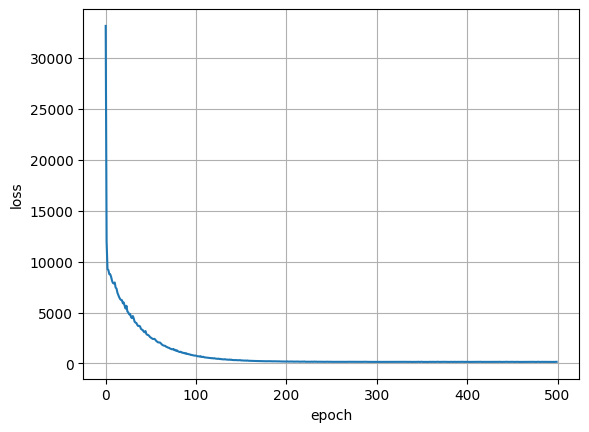

In [222]:
# Loss function plot
plt.plot(L);
plt.xlabel('epoch');
plt.ylabel('loss');
plt.grid();

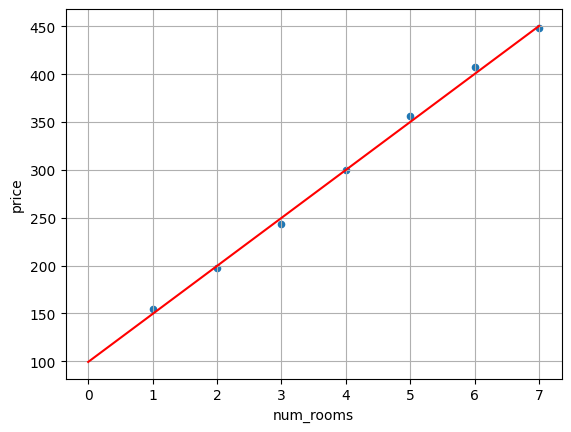

In [223]:
# Regression line plot
ax = houses.plot.scatter (x="num_rooms", y='price', grid=True)
num_rooms_range = np.arange(0, 8)
plt.plot(num_rooms_range, a[-1] * num_rooms_range + b[-1], 'r-');

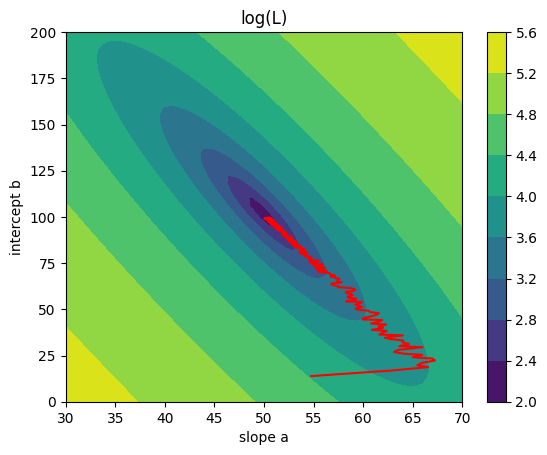

In [224]:
# Create a 2D contour plot of the loss function and add the path followed by SGD

# calculating SSE for a 50 x 50 grid of (a, b) nodes
n = 50
a_range = np.linspace(30, 70, n)
b_range = np.linspace(0, 200, n)

L_grid = np.zeros((n, n))
for i, a_value in enumerate(a_range):
    for j, b_value in enumerate(b_range):
        L_grid[i, j] = np.sum((houses['price'] - (a_value * houses['num_rooms'] + b_value)) ** 2)

# contour plot of log10(L) with path followed by SGD
plt.contourf(a_range, b_range, np.log10(L_grid));  # filled contour plot
plt.plot(a, b, 'r-');  # path followed by SGD
plt.xlabel('slope a');
plt.ylabel('intercept b');
plt.title('log(L)');
plt.colorbar();

### Exercise 9

Apply Stochastic Gradient Descent (SGD) to the `zwift.csv` dataset from the introduction of this topic. Use the obtained model to predict the distance after 2 hours of cycling.

**Attention!** We know that the distance is 0 km after 0 hours of cycling. Therefore, we must fit a straight line that passes through the origin!  

Modify the `SGD()` function to ensure that the regression line always passes through the origin.

Plot the result and the progression of the loss function again.

In [225]:
# Read dataset
import pandas as pd
zwift = pd.read_csv('zwift.csv', sep=';')
zwift.head()

,tijd (min),afstand (km)
0,0,0.00
1,1,0.14
2,2,1.01
3,3,1.32
4,4,1.55


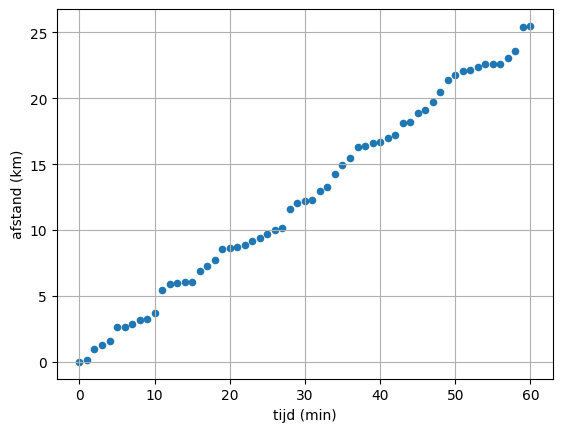

In [226]:
# Scatterplot of the dataset
xlabel, ylabel = tuple(zwift.columns)
zwift.plot.scatter(x=xlabel, y=ylabel, grid=True);

It is always a good idea to scale the data because the SGD algorithm doesn't like big numbers. So we gonna divide both time and distance values by their respective maximum:

In [227]:
x = zwift[xlabel].values / 60
y = zwift[ylabel].values / 25

We first apply the SGD algorithm where we optimize both slope `a` and intercept `b`:

In [228]:
# Apply Stochastic Gradient Descent
a, b, loss = SGD(x, y, n_epochs = 250, alpha = 1e-2, seed=0)
print(f"slope = {a[-1]}\nintercept = {b[-1]}")
print(f"SSE = {loss[-1]}")

slope = 1.0049412610076283
intercept = -0.000579910733267809
SSE = 0.022949662324975893


The intercept `b` is very close to 0, but is not exactly equal to 0! Let's plot loss scores vs epochs:

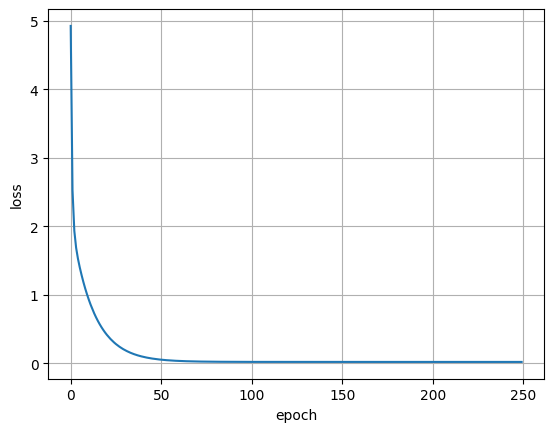

In [229]:
# Loss function plot
plt.plot(loss);
plt.xlabel('epoch');
plt.ylabel('loss');
plt.grid();

And we predict the distance after 2 hours of cycling:

In [230]:
xnew = 120  # 2 hours = 60 minutes
xnew /= 60  # xnew is also scaled!
yp = a[-1] * xnew + b[-1]  # prediction yp is the distance divided by 25!
yp *= 25    # convert back to km

print(f"The predicted distance is {yp} km after 2 hours of cycling.")

The predicted distance is 50.23256528204971 km after 2 hours of cycling.


Plotting the regression line:

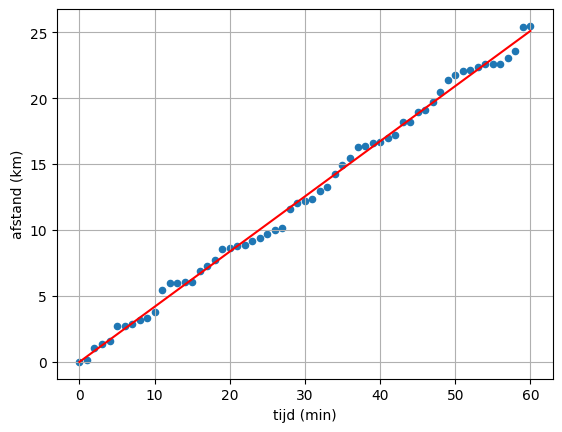

In [231]:
zwift.plot.scatter(x=xlabel, y=ylabel, grid=True)
plt.plot(x * 60, 25 * (a[-1] * x + b[-1]), 'r-');

In this case, however, we know that the straight line must go through the origin, or therefore, that intercept `b` is exactly equal to 0. We extend the SGD algorithm so that it is possible to only optimize slope `a` by introducting input parameter `fit_intercept` which is `True` by default:

In [232]:
# The Stochastic Gradient Descent (SGD) Algorithm
# version where it is not required to optimize the intercept

def SGD(x, y, n_epochs, alpha, fit_intercept=True, seed=None):
    """
    Stochastic Gradient Descent (SGD) algorithm for simple linear regression

    Input parameters:
    - x: array with values of the independent variable (length is n)
    - y: array with corresponding values of the dependent variable (length is n)
    - n_epochs: integer determining the number of epochs
    - alpha: float defining the learning rate
    - fit_intercept: boolean determining whether to optimize the intercept (default is True)
    - seed (optional): seed for the random number generator (default is None)

    Return values:
    - a: array with slope derived after each epoch (length is n_epochs)
    - b: array with intercept derived after each epoch (length is n_epochs)
    - L: array with SSE calculated after each epoch (length is n_epochs)

    The optimal values for slope and intercept are a[-1] en b[-1],
    and the corresponding SSE is L[-1]
    """

    # initialisation
    if seed is not None: np.random.seed(seed)
    a = np.random.rand()
    b = np.random.rand() if fit_intercept else 0.0
    a_path, b_path = [], []  # keep track of a and b derived after each epoch
    L = []  # keep track of loss score calculated after each epoch
    idx = list(range(len(x)))  # indices of the data points

    # outer loop: epochs
    for _ in range(n_epochs):
        np.random.shuffle(idx)  # shuffle indices

        # inner loop: data points
        for i in idx:
            yp = a * x[i] + b  # prediction
            delta = alpha * (y[i] - yp)
            a += delta * x[i]  # adjust slope
            if fit_intercept: b += delta  # adjust intercept

        a_path.append(a)
        b_path.append(b)
        L.append(np.sum((y - (a * x + b)) ** 2))  # loss function: sum of squared residuals SSE

    # output
    return np.array(a_path), np.array(b_path), np.array(L)

Now we apply Stochastic Gradient Descent without fitting intercept `b` by setting `fit_intercept` to `False`:

In [233]:
a, b, loss = SGD(x, y, n_epochs = 100, alpha = 1e-2, fit_intercept=False, seed=0)
print(f"slope = {a[-1]}\nintercept = {b[-1]}")
print(f"SSE = {loss[-1]}")

slope = 1.004382224022513
intercept = 0.0
SSE = 0.02294821740553823


Let's plot the loss function:

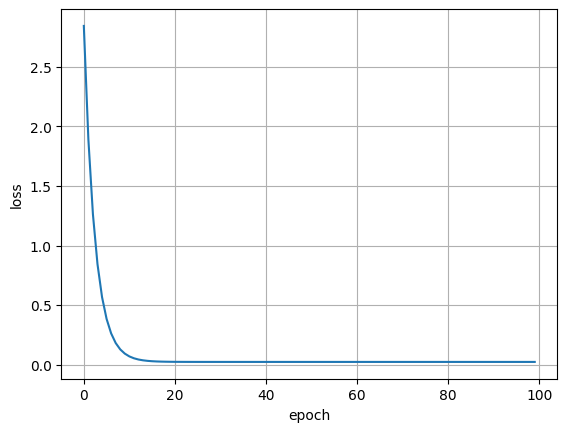

In [234]:
plt.plot(loss);
plt.xlabel('epoch');
plt.ylabel('loss');
plt.grid();

Let's predict the distance after two hours of cycling using this new model:

In [235]:
xnew = 120  # 2 hours = 60 minutes
xnew /= 60  # xnew is also scaled!
yp = a[-1] * xnew  # prediction yp is the distance divided by 25!
yp *= 25    # convert back to km

print(f"The predicted distance is {yp} km after 2 hours of cycling.")

The predicted distance is 50.219111201125656 km after 2 hours of cycling.


Finally, we plot the regression line, which now passes through the origin, making more physical sense!

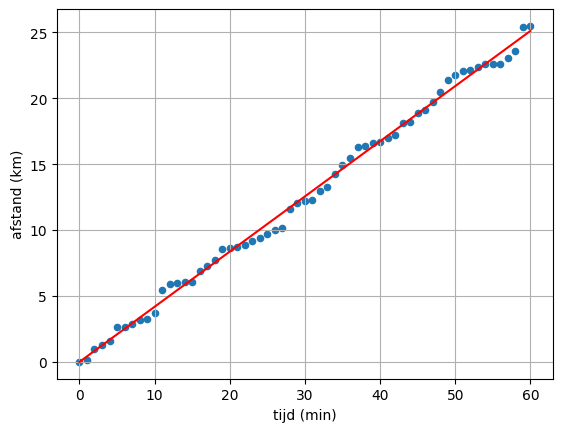

In [236]:
zwift.plot.scatter(x=xlabel, y=ylabel, grid=True)
plt.plot(x * 60, 25 * a[-1] * x, 'r-');

As an illustration, the path followed by SGD to approximate the minimum of the loss function is plotted. Because we only have 1 parameter, slope `a`, it can be visualized easily by a 2D line plot:

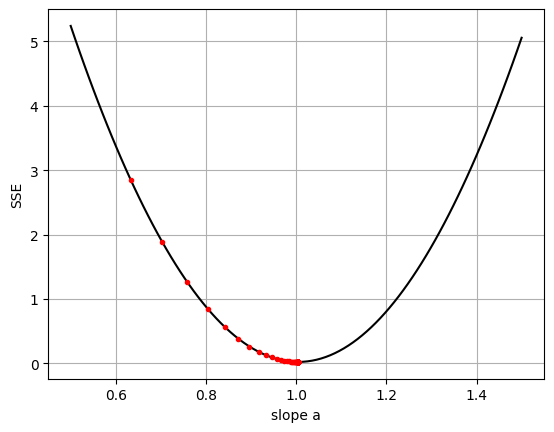

In [237]:
a_range = np.linspace(0.5, 1.5, 100)  # generate a range of 'a' values
SSE = [np.sum((y - (a * x)) ** 2) for a in a_range]  # calculate the SSE for these 'a' values

plt.plot(a_range, SSE, 'k-');  # plot of SSE as a function of parameter 'a'
plt.plot(a, loss, 'r.');  # plot of 'a' values iteratively derived by SGD and corresponding SSE
plt.xlabel('slope a');
plt.ylabel('SSE');
plt.grid();

### Exercise 10

- Read the file 'linkedIn.csv' into a Pandas DataFrame. Using this dataset, you will predict a person's salary based on the number of LinkedIn connections they have.
- Print the first 5 rows of the DataFrame, get a concise summary by calling method `info`, and give the summary statistics by using the `describe` method.
- Make a scatter plot of the data. In Dutch, "loon" means "salary", while "connecties" are the "connections" on LinkedIn.
- Apply Stochastic Gradient Descent (SGD) to fit a straight line through the data points.
- There's a good chance that you'll get an **overflow error**. How does that happen? How could you solve that?
- Plot the evolution of the loss function and print the optimal parameter values derived by SGD.
- Draw the obtained regression line on the scatter plot that you have made earlier.
- Calculate the MSE and the MAE using the data that are not scaled.
- Someone in your circle of friends has 252 connections on LinkedIn. Give an estimate of that person monthly salary.
- Can the real salary of that person be increased by increasing the number of connections on LinkedIn?
- Finally, use Scikit-Learn to fit the data and make the prediction. Do you get the same result? Explain!


In [277]:
# Read the csv-file
df = pd.read_csv('linkedIn.csv')
df.head()  # show first 5 rows

,loon,connecties
0,3252,304
1,2968,216
2,2976,159
3,3255,273
4,1953,191


In [278]:
# Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2064 entries, 0 to 2063
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   loon        2064 non-null   int64
 1   connecties  2064 non-null   int64
dtypes: int64(2)
memory usage: 32.4 KB


In [279]:
# Get summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loon,2064.0,2526.755329,984.928461,901.0,1784.0,2394.5,3154.25,5974.0
connecties,2064.0,210.377907,94.437076,7.0,141.0,205.0,270.00,549.0


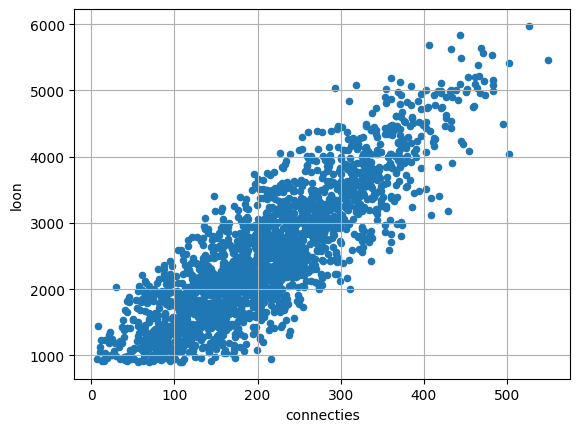

In [280]:
# Make a scatter plot
# We want to predict salary based on connections, so x="connecties" and y="loon"!
df.plot.scatter(x="connecties", y="loon", grid=True);

In [281]:
# Apply Stochastic Gradient Descent
a, b, L = SGD(x=df.connecties.values, y=df.loon.values,
              n_epochs=10, alpha=0.001, seed=0)
a[-1], b[-1], L[-1]

<ipython-input-232-e78eb2af9e4c>:39: RuntimeWarning: overflow encountered in scalar multiply
  yp = a * x[i] + b  # prediction
<ipython-input-232-e78eb2af9e4c>:41: RuntimeWarning: invalid value encountered in scalar add
  a += delta * x[i]  # adjust slope
<ipython-input-232-e78eb2af9e4c>:42: RuntimeWarning: invalid value encountered in scalar add
  if fit_intercept: b += delta  # adjust intercept


(nan, nan, nan)

In [282]:
# We get an overflow error!
# To prevent this error, we need to scale the variables!
x = df.connecties.values / 600
y = df.loon.values / 6000

In [297]:
# Retry Stochastic Gradient Descent
a, b, L = SGD(x=x, y=y,
              n_epochs=1000, alpha=0.0001, seed=0)

print(f"slope = {a[-1]:.5f}\nintercept = {b[-1]:.5f}")
print(f"SSE = {L[-1]:.5f}")

slope = 0.88601
intercept = 0.11050
SSE = 14.99173


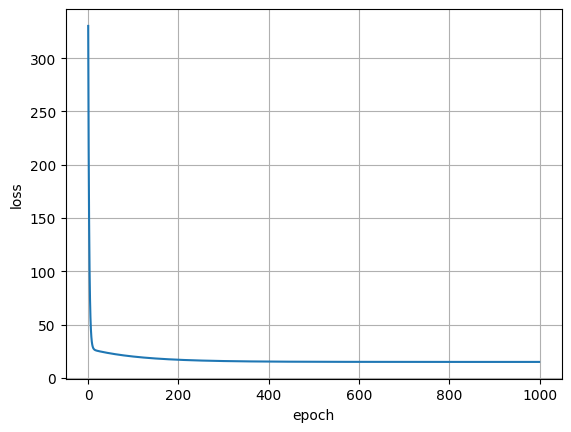

In [298]:
# Plot loss vs epoch
plt.plot(L);
plt.xlabel('epoch');
plt.ylabel('loss');
plt.grid();

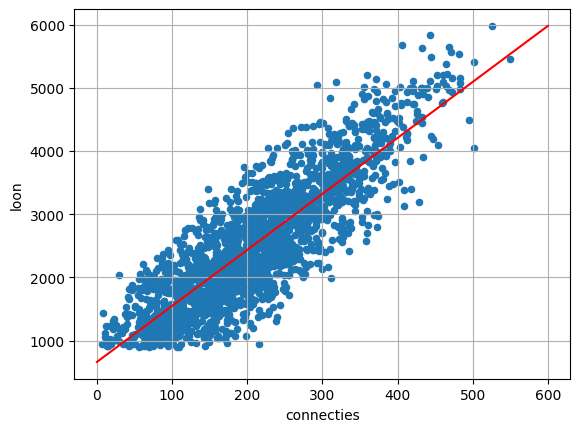

In [299]:
# Regression line plot
ax = df.plot.scatter (x="connecties", y='loon', grid=True)
x_line = np.array([0, 1])
y_line = a[-1] * x_line + b[-1]
plt.plot(x_line * 600, y_line * 6000, 'r-');

In [304]:
# Calculate MSE and MAE
y_true = df.loon.values  # true values
y_pred = (a[-1] * x + b[-1]) * 6000  # predicted values
residuals = y_true - y_pred  # residuals
print(f"MSE = {np.square(residuals).mean():.2f}")
print(f"MAE = {np.abs(residuals).mean():.2f}")

MSE = 261483.60
MAE = 404.86


In [309]:
# Predict salary for 252 connections
xnew = 252
yp = (a[-1] * xnew / 600 + b[-1]) * 6000
print(f"The predicted salary for someone with {xnew} connections is {yp:.2f}")
print("Linear regression expresses correlation, not causation!\n",
      "Therefore, increasing someone's LinkedIn connections will not necessarily increase their salary.",
      sep="")

The predicted salary for someone with 252 connections is 2895.77
Linear regression expresses correlation, not causation!
Therefore, increasing someone's LinkedIn connections will not necessarily increase their salary.


In [305]:
# Check the result using Scikit-Learn
from sklearn.linear_model import LinearRegression
LR = LinearRegression()
LR.fit(x.reshape(-1, 1), y)
print(f"slope = {LR.coef_[0]:.5f}\nintercept = {LR.intercept_:.5f}")
yp = LR.predict([[xnew / 600]])[0] * 6000
print(f"The predicted salary for someone with {xnew} connections is {yp:.2f}")

slope = 0.89131
intercept = 0.10861
The predicted salary for someone with 252 connections is 2897.74


In [307]:
# Calculate MSE and MAE using sklearn functions
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE
y_true = df.loon.values
y_pred = LR.predict(x.reshape(-1, 1)) * 6000
print(f"MSE = {MSE(y_true=y_true, y_pred=y_pred):.2f}")
print(f"MAE = {MAE(y_true=y_true, y_pred=y_pred):.2f}")

MSE = 261458.55
MAE = 404.66


We see that the solution derived by **Stochastic Gradient Descent (SGD) is an approximation of the exact solution provided by the Ordinary Least Squares (OLS) method** implemented in Scikit-Learn!

We also learned that **scaling features** in machine learning is important for several reasons:

- *Ensuring Equal Contribution:* Different features in your data may have different units or ranges (e.g., age might range from 0 to 100, while income could range from 1,000 to 100,000). If you don't scale them, features with larger numerical ranges could dominate the learning process, leading the model to give more importance to those features, potentially skewing the results.

- *Improving Algorithm Performance:* Many machine learning algorithms, like Stochastic Gradient Descent, perform better when the features are scaled. For example, algorithms that rely on distances between points are sensitive to the scale of features. If one feature has a much larger scale than others, it can affect the model's ability to measure distances accurately.

- *Ensuring Convergence in Optimization Algorithms:* For algorithms that involve optimization, such as Stochastic Gradient Descent, scaling helps in faster convergence. When features are on a similar scale, the optimization process becomes smoother and may require fewer iterations to find the optimal parameters.

- *Preventing Numerical Instability:* In some algorithms, like Stochastic Gradient Descent, unscaled variables can lead to issues with numerical stability, where small changes in certain features can lead to large, erratic updates in the model's weights or predictions. Think about the overflow error we encountered in this exercise before we scaled the features!

---